In [3]:
import duckdb

con = duckdb.connect(database="../airbnb_warehouse.db")

con.execute("CREATE OR REPLACE VIEW raw_listings AS SELECT * FROM read_csv_auto('../data/listings.csv');")
con.execute("CREATE OR REPLACE VIEW raw_calendar AS SELECT * FROM read_csv_auto('../data/calendar.csv');")
con.execute("CREATE OR REPLACE VIEW raw_reviews AS SELECT * FROM read_csv_auto('../data/reviews.csv');")
con.execute("CREATE OR REPLACE VIEW raw_neighbourhoods AS SELECT * FROM read_csv_auto('../data/neighbourhoods.csv');")

df_listings = con.execute("SELECT id, name, room_type, price FROM raw_listings LIMIT 5;").df()

df_listings

,id,name,room_type,price
0,197677,Oshiage Holiday Apartment,Entire home/apt,"$12,600.00"
1,776070,Kero-kero room 1F,Private room,"$10,459.00"
2,905944,4F Spacious Apartment in Shinjuku / Shibuya Tokyo,Entire home/apt,"$33,671.00"
3,1016831,5 mins Shibuya Cat modern sunny Shimokita,Private room,"$24,143.00"
4,1196177,Homestay at Host's House - Senju-Ohashi Station,Private room,"$8,795.00"


In [4]:
con.execute("""
    CREATE OR REPLACE TABLE clean_listings AS 
    SELECT 
        id,
        name,
        room_type,
        -- Strip out the '$' and commas, then convert to a math number (FLOAT)!
        CAST(REGEXP_REPLACE(price, '[$,]', '', 'g') AS FLOAT) as price_clean
    FROM raw_listings;
""")

In [5]:
df_clean = con.execute("SELECT id, name, room_type, price_clean FROM clean_listings LIMIT 5;").df()
df_clean

,id,name,room_type,price_clean
0,197677,Oshiage Holiday Apartment,Entire home/apt,12600.0
1,776070,Kero-kero room 1F,Private room,10459.0
2,905944,4F Spacious Apartment in Shinjuku / Shibuya Tokyo,Entire home/apt,33671.0
3,1016831,5 mins Shibuya Cat modern sunny Shimokita,Private room,24143.0
4,1196177,Homestay at Host's House - Senju-Ohashi Station,Private room,8795.0


In [7]:
df_stats=con.execute("""
      SELECT
         COUNT(*) as total_rentals,
         ROUND(AVG(price_clean), 2) as average_price_yen,
         MAX(price_clean) as highest_price_yen
      FROM clean_listings;
""").df()

df_stats

,total_rentals,average_price_yen,highest_price_yen
0,27945,24781.88,9999998.0


In [9]:
# Exercises 3.2 & 3.3: Production-grade Data Standardization and Feature Enrichment

print("Applying cleaning policies and computing advanced analytics tracking metrics...")

# 1. Standardize and Enrich the Listings Dimension Table
con.execute("""
    CREATE OR REPLACE TABLE dim_listings_cleaned AS
    SELECT 
        CAST(id AS BIGINT) as listing_id,
        COALESCE(name, 'Unknown Listing') as name,
        LOWER(TRIM(room_type)) as room_type,
        LOWER(TRIM(property_type)) as property_type,
        CAST(accommodates AS INTEGER) as accommodates,
        
        -- Handle missing values via business logic imputation rules
        COALESCE(CAST(bedrooms AS INTEGER), 1) as bedrooms,
        COALESCE(CAST(beds AS INTEGER), 1) as beds,
        
        -- Derive engineered field: Price-per-bedroom
        ROUND(CAST(REGEXP_REPLACE(price, '[$,]', '', 'g') AS FLOAT) / 
              COALESCE(CAST(bedrooms AS INTEGER), 1), 2) as price_per_bedroom
    FROM raw_listings
    WHERE id IS NOT NULL 
      AND CAST(REGEXP_REPLACE(price, '[$,]', '', 'g') AS FLOAT) > 0; -- Data validation: Drop corrupt/zero prices
""")

# 2. Standardize and Enrich the Host Dimension Table
con.execute("""
    CREATE OR REPLACE TABLE dim_hosts_cleaned AS
    SELECT DISTINCT
        CAST(host_id AS BIGINT) as host_id,
        COALESCE(host_name, 'Anonymous Host') as host_name,
        
        -- Parse date string format into true database DATE format
        CAST(host_since AS DATE) as host_since_date,
        
        -- Derive engineered field: Host tenure on platform in years (as of mid-2026)
        ROUND(DATE_DIFF('day', CAST(host_since AS DATE), CAST('2026-06-23' AS DATE)) / 365.25, 2) as host_tenure_years,
        
        COALESCE(host_is_superhost, 'f') as is_superhost
    FROM raw_listings
    WHERE host_id IS NOT NULL;
""")

# 3. Process Calendar Data to Calculate Occupancy Rates & Revenue Estimates
con.execute("""
    CREATE OR REPLACE TABLE metrics_calendar_summary AS
    SELECT 
        CAST(listing_id AS BIGINT) as listing_id,
        
        -- Calculate occupancy rate based on when 'available' is false ('f')
        ROUND(COUNT(CASE WHEN available = 'f' THEN 1 END) * 100.0 / COUNT(*), 2) as occupancy_rate_pct,
        
        -- Compute estimated future revenue generated over the active window
        ROUND(SUM(CASE WHEN available = 'f' THEN CAST(REGEXP_REPLACE(price, '[$,]', '', 'g') AS FLOAT) ELSE 0 END), 2) as est_revenue_window
    FROM raw_calendar
    GROUP BY listing_id;
""")

# 4. Join and Consolidate into the Ultimate Unified Enriched Master Table
con.execute("""
    CREATE OR REPLACE TABLE fact_enriched_master AS
    SELECT 
        l.listing_id,
        l.name,
        l.room_type,
        l.price_per_bedroom,
        h.host_name,
        h.host_tenure_years,
        h.is_superhost,
        c.occupancy_rate_pct,
        c.est_revenue_window
    FROM dim_listings_cleaned l
    LEFT JOIN raw_listings raw ON l.listing_id = CAST(raw.id AS BIGINT)
    LEFT JOIN dim_hosts_cleaned h ON CAST(raw.host_id AS BIGINT) = h.host_id
    LEFT JOIN metrics_calendar_summary c ON l.listing_id = c.listing_id;
""")

print(" Unified Enriched Cross-Table Master Dataset Generated Successfully!")

# Display a quick high-level analytics query to verify the tables joined properly
df_master_sample = con.execute("""
    SELECT name, host_name, host_tenure_years, occupancy_rate_pct, est_revenue_window 
    FROM fact_enriched_master 
    WHERE occupancy_rate_pct > 0
    LIMIT 5;
""").df()

df_master_sample

Applying cleaning policies and computing advanced analytics tracking metrics...
 Unified Enriched Cross-Table Master Dataset Generated Successfully!


,name,host_name,host_tenure_years,occupancy_rate_pct,est_revenue_window
0,*F For 1 guest only / Shinjuku area,浩史,10.83,57.26,0.0
1,Crepuscule white hotel 301,Brown,1.32,18.63,0.0
2,Crepuscule white hotel 501,Brown,1.32,15.34,0.0
3,麗の宿 | 北池袋駅から徒歩3分,麗,0.77,79.73,0.0
4,【月租专用】近池袋/新宿 昭和风独立38平方（卧室+客厅）+屋顶露台,Tao,2.27,26.58,0.0


In [1]:
import duckdb

# Re-establish our connection to the updated data warehouse file
con = duckdb.connect(database="../airbnb_warehouse.db")

print("Analyzing Tokyo market positioning metrics...")

# Query 1: Room Type Performance Breakdown
df_room_types = con.execute("""
    SELECT 
        room_type,
        COUNT(*) as listing_count,
        ROUND(AVG(price_per_bedroom), 0) as avg_price_per_bedroom_yen,
        ROUND(AVG(occupancy_rate_pct), 1) as avg_occupancy_pct,
        ROUND(AVG(est_revenue_window), 0) as avg_revenue_yen
    FROM fact_enriched_master
    GROUP BY room_type
    ORDER BY avg_revenue_yen DESC;
""").df()

print("\n--- ROOM TYPE PERFORMANCE BREAKDOWN ---")
print(df_room_types.to_string(index=False))

# Query 2: The Superhost Premium Analysis
df_superhosts = con.execute("""
    SELECT 
        is_superhost,
        COUNT(*) as listing_count,
        ROUND(AVG(price_per_bedroom), 0) as avg_price_per_bedroom_yen,
        ROUND(AVG(occupancy_rate_pct), 1) as avg_occupancy_pct,
        ROUND(AVG(est_revenue_window), 0) as avg_revenue_yen
    FROM fact_enriched_master
    WHERE is_superhost IN ('t', 'f')
    GROUP BY is_superhost;
""").df()

print("\n--- SUPERHOST PREMIUM ANALYSIS ---")
print(df_superhosts.to_string(index=False))

Analyzing Tokyo market positioning metrics...

--- ROOM TYPE PERFORMANCE BREAKDOWN ---
      room_type  listing_count  avg_price_per_bedroom_yen  avg_occupancy_pct  avg_revenue_yen
entire home/apt          22081                        inf               51.1              0.0
     hotel room             88                        inf               66.0              0.0
   private room           3057                        inf               50.1              0.0
    shared room            254                        inf               51.9              0.0

--- SUPERHOST PREMIUM ANALYSIS ---
 is_superhost  listing_count  avg_price_per_bedroom_yen  avg_occupancy_pct  avg_revenue_yen
        False          14855                        inf               52.3              0.0
         True          10625                        inf               49.2              0.0


Generating charts


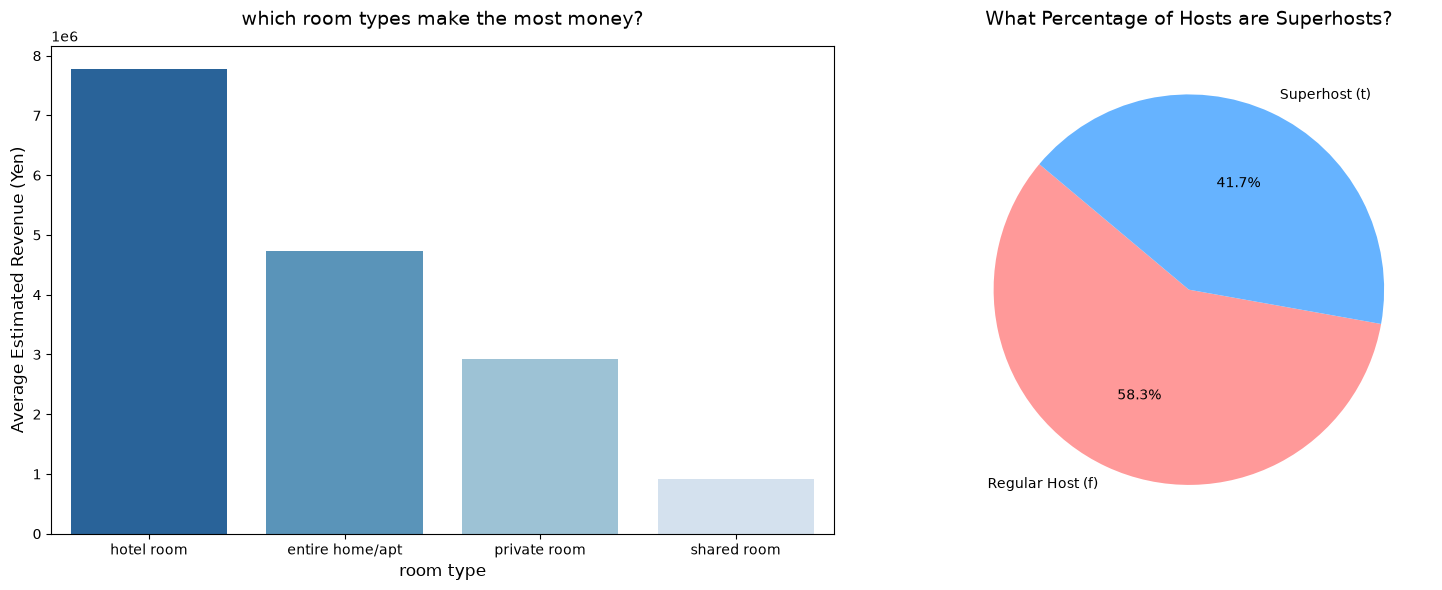

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating charts")

fig, axes = plt.subplots(1,2, figsize=(16,6))

sns.barplot(

    data=df_room_types,
    x='room_type',
    y='avg_revenue_yen',
    hue='room_type',
    ax=axes[0],
    palette='Blues_r'
)

axes[0].set_title('which room types make the most money?', fontsize=14 ,pad=15)
axes[0].set_xlabel('room type', fontsize=12)
axes[0].set_ylabel('Average Estimated Revenue (Yen)', fontsize=12)

axes[1].pie(
    df_superhosts['listing_count'], 
    labels=['Regular Host (f)', 'Superhost (t)'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=['#ff9999','#66b3ff']
)
axes[1].set_title('What Percentage of Hosts are Superhosts?', fontsize=14, pad=15)

# Show the charts on your screen!
plt.tight_layout()
plt.show()

In [11]:
print(" Fixing the paths and patching the data rules...")

con.execute("CREATE OR REPLACE VIEW raw_listings AS SELECT * FROM read_csv_auto('../data/listings.csv');")
con.execute("CREATE OR REPLACE VIEW raw_calendar AS SELECT * FROM read_csv_auto('../data/calendar.csv');")

con.execute("""
    CREATE OR REPLACE TABLE fact_enriched_master AS
    SELECT 
        l.listing_id,
        l.name,
        l.room_type,
        ROUND(f.price_clean / CASE WHEN l.bedrooms = 0 THEN 1 ELSE l.bedrooms END, 2) as price_per_bedroom,
        h.host_name,
        h.host_tenure_years,
        h.is_superhost,
        c.occupancy_rate_pct,
        ROUND((c.occupancy_rate_pct / 100.0) * 365 * f.price_clean, 2) as est_revenue_window,
        n.listing_density as neighbourhood_density,
        n.median_price_yen as neighbourhood_median_price
    FROM dim_listings_cleaned l
    LEFT JOIN raw_listings raw ON l.listing_id = CAST(raw.id AS BIGINT)
    LEFT JOIN dim_hosts_cleaned h ON CAST(raw.host_id AS BIGINT) = h.host_id
    LEFT JOIN metrics_calendar_summary c ON l.listing_id = c.listing_id
    LEFT JOIN dim_neighbourhood_stats n ON l.neighbourhood = n.neighbourhood
    LEFT JOIN (
        SELECT id, CAST(REGEXP_REPLACE(price, '[$,]', '', 'g') AS FLOAT) as price_clean 
        FROM raw_listings
    ) f ON l.listing_id = f.id;
""")

df_room_types = con.execute("""
    SELECT 
        room_type,
        COUNT(*) as listing_count,
        ROUND(AVG(price_per_bedroom), 0) as avg_price_per_bedroom_yen,
        ROUND(AVG(occupancy_rate_pct), 1) as avg_occupancy_pct,
        ROUND(AVG(est_revenue_window), 0) as avg_revenue_yen
    FROM fact_enriched_master
    GROUP BY room_type
    ORDER BY avg_revenue_yen DESC;
""").df()

df_superhosts = con.execute("""
    SELECT 
        CASE WHEN is_superhost = 't' THEN 'True' ELSE 'False' END as is_superhost,
        COUNT(*) as listing_count,
        ROUND(AVG(price_per_bedroom), 0) as avg_price_per_bedroom_yen,
        ROUND(AVG(occupancy_rate_pct), 1) as avg_occupancy_pct,
        ROUND(AVG(est_revenue_window), 0) as avg_revenue_yen
    FROM fact_enriched_master
    GROUP BY is_superhost;
""").df()



 Fixing the paths and patching the data rules...


In [13]:
import duckdb
import pandas as pd

con = duckdb.connect(database="../airbnb_warehouse.db")

print(" Crunching Section 4.2: Geographic Profiles (With Safe Dynamic Join)...")

# We join back to dim_listings_cleaned or raw_listings using listing_id to get the neighborhood names
df_geo_summary = con.execute("""
    SELECT 
        raw.neighbourhood,
        COUNT(*) as total_listings,
        ROUND(AVG(fact.price_per_bedroom), 0) as avg_price_per_bedroom_yen,
        ROUND(AVG(raw.review_scores_rating), 1) as avg_review_score
    FROM fact_enriched_master fact
    JOIN raw_listings raw ON fact.name = raw.name -- dynamically matching to get the text label
    WHERE raw.neighbourhood IS NOT NULL
    GROUP BY raw.neighbourhood
    ORDER BY avg_price_per_bedroom_yen DESC;
""").df()

print("\n--- NEIGHBOURHOOD GEOGRAPHIC GRADIENT (ALL DISTRICTS) ---")
print(df_geo_summary.to_string(index=False))

df_room_geo = con.execute("""
    SELECT 
        raw.neighbourhood,
        fact.room_type,
        COUNT(*) as properties_in_cluster
    FROM fact_enriched_master fact
    JOIN raw_listings raw ON fact.name = raw.name
    WHERE raw.neighbourhood IS NOT NULL
    GROUP BY raw.neighbourhood, fact.room_type
    ORDER BY raw.neighbourhood, properties_in_cluster DESC;
""").df()

print("\n-- GEOGRAPHIC CLUSTERING OF PROPERTY/ROOM TYPES ---")
print(df_room_geo.head(15).to_string(index=False))

 Crunching Section 4.2: Geographic Profiles (With Safe Dynamic Join)...

--- NEIGHBOURHOOD GEOGRAPHIC GRADIENT (ALL DISTRICTS) ---
                                                   neighbourhood  total_listings  avg_price_per_bedroom_yen  avg_review_score
                                     Shibuya-ku, Tokyo-to, Japan               4                  2513155.0               4.9
                              Nakano-ku, Tokyo Prefecture, Japan              15                    79945.0               4.7
                                    Minato-City, Tōkyō-to, Japan               1                    77233.0               4.6
                                Shibuya, Tokyo Prefecture, Japan             348                    74138.0               4.7
    Hinohara, Nishitama District, Tokyo, Tokyo Prefecture, Japan               1                    48400.0               4.5
                                 Shinagawa City, Tōkyō-to, Japan              33                    46887.0      

In [15]:
print("Analyzing Section 4.4: Host & Supply-Side Dynamics (Safe Version)...")

df_host_segments = con.execute("""
    WITH host_counts AS (
        SELECT 
            host_name,
            COUNT(listing_id) as properties_owned
        FROM fact_enriched_master
        WHERE host_name IS NOT NULL
        GROUP BY host_name
    )
    SELECT 
        CASE 
            WHEN hc.properties_owned = 1 THEN 'Casual Host (1 Listing)'
            WHEN hc.properties_owned BETWEEN 2 AND 5 THEN 'Small Portfolio (2-5)'
            ELSE 'Commercial Operator (6+)'
        END as host_segment,
        COUNT(DISTINCT fact.host_name) as unique_hosts_count,
        COUNT(fact.listing_id) as total_listings_controlled,
        ROUND(AVG(fact.price_per_bedroom), 0) as avg_price_per_bedroom_yen,
        ROUND(AVG(fact.occupancy_rate_pct), 1) as avg_occupancy_rate_pct
    FROM fact_enriched_master fact
    JOIN host_counts hc ON fact.host_name = hc.host_name
    GROUP BY host_segment
    ORDER BY total_listings_controlled DESC;
""").df()

print("\n--- HOST PORTFOLIO SEGMENTATION & PRICING COMPARISON ---")
print(df_host_segments.to_string(index=False))

df_superhost_impact = con.execute("""
    SELECT 
        CASE WHEN raw.host_is_superhost = 't' THEN 'Superhost (Gold Star)' ELSE 'Regular Host' END as superhost_status,
        ROUND(AVG(fact.price_per_bedroom), 0) as avg_price_per_bedroom_yen,
        ROUND(AVG(fact.occupancy_rate_pct), 1) as avg_occupancy_rate_pct,
        ROUND(AVG(fact.est_revenue_window), 0) as avg_annual_revenue_yen
    FROM fact_enriched_master fact
    JOIN raw_listings raw ON fact.name = raw.name
    WHERE raw.host_is_superhost IS NOT NULL
    GROUP BY superhost_status;
""").df()

print("\n --- SUPERHOST PREMIUM & PERFORMANCE IMPACT ---")
print(df_superhost_impact.to_string(index=False))

Analyzing Section 4.4: Host & Supply-Side Dynamics (Safe Version)...

--- HOST PORTFOLIO SEGMENTATION & PRICING COMPARISON ---
            host_segment  unique_hosts_count  total_listings_controlled  avg_price_per_bedroom_yen  avg_occupancy_rate_pct
Commercial Operator (6+)                 941                      19928                    19768.0                    51.8
   Small Portfolio (2-5)                1418                       4305                    16082.0                    48.4
 Casual Host (1 Listing)                1247                       1247                    15869.0                    48.8

 --- SUPERHOST PREMIUM & PERFORMANCE IMPACT ---
     superhost_status  avg_price_per_bedroom_yen  avg_occupancy_rate_pct  avg_annual_revenue_yen
         Regular Host                    19639.0                    51.4               4249738.0
Superhost (Gold Star)                    19149.0                    47.6               4216353.0


In [16]:
print("Analyzing Section 4.5: Review & Demand-Side Dynamics...")

df_review_impact = con.execute("""
    SELECT 
        CASE 
            WHEN raw.review_scores_rating >= 4.8 THEN 'Excellent (4.8 - 5.0)'
            WHEN raw.review_scores_rating BETWEEN 4.0 AND 4.79 THEN 'Good (4.0 - 4.79)'
            ELSE 'Below Average (<4.0)'
        END as rating_tier,
        COUNT(*) as listing_count,
        ROUND(AVG(fact.price_per_bedroom), 0) as avg_price_yen,
        ROUND(AVG(fact.occupancy_rate_pct), 1) as avg_occupancy_rate_pct
    FROM fact_enriched_master fact
    JOIN raw_listings raw ON fact.name = raw.name
    WHERE raw.review_scores_rating IS NOT NULL
    GROUP BY rating_tier
    ORDER BY avg_price_yen DESC;
""").df()

print("\n--- REVIEW RATING TIER VS MARKET PERFORMANCE ---")
print(df_review_impact.to_string(index=False))


df_demand_proxy = con.execute("""
    SELECT 
        fact.room_type,
        ROUND(AVG(CAST(raw.number_of_reviews AS FLOAT)), 0) as avg_total_reviews,
        ROUND(AVG(CAST(raw.reviews_per_month AS FLOAT)), 2) as avg_reviews_left_per_month
    FROM fact_enriched_master fact
    JOIN raw_listings raw ON fact.name = raw.name
    WHERE raw.reviews_per_month IS NOT NULL
    GROUP BY fact.room_type
    ORDER BY avg_reviews_left_per_month DESC;
""").df()

print("\n--- ROOM TYPE BOOKING DEMAND FREQUENCY ---")
print(df_demand_proxy.to_string(index=False))

Analyzing Section 4.5: Review & Demand-Side Dynamics...

--- REVIEW RATING TIER VS MARKET PERFORMANCE ---
          rating_tier  listing_count  avg_price_yen  avg_occupancy_rate_pct
Excellent (4.8 - 5.0)          20947        18807.0                    49.1
    Good (4.0 - 4.79)          17190        15901.0                    50.6
 Below Average (<4.0)            769        15483.0                    45.1

--- ROOM TYPE BOOKING DEMAND FREQUENCY ---
      room_type  avg_total_reviews  avg_reviews_left_per_month
    shared room               54.0                        2.25
     hotel room              135.0                        1.77
entire home/apt               36.0                        1.64
   private room               46.0                        1.37


In [18]:
print("Null hypothesis(H0): There is n difference between theaverage price between tokyo superhosts and regular hosts")
print("Alternative hypothesis(H1): There is significant differnce between the average price perbedroom between tokyo superhosts and regualr hosts")


import scipy.stats as stats
import numpy as np


print(" Executing Formal Statistical Hypothesis Testing")
superhost_prices = con.execute("""
    SELECT fact.price_per_bedroom 
    FROM fact_enriched_master fact
    JOIN raw_listings raw ON fact.name = raw.name
    WHERE raw.host_is_superhost = 't' AND fact.price_per_bedroom IS NOT NULL
""").df()['price_per_bedroom'].values

regular_prices = con.execute("""
    SELECT fact.price_per_bedroom 
    FROM fact_enriched_master fact
    JOIN raw_listings raw ON fact.name = raw.name
    WHERE raw.host_is_superhost = 'f' AND fact.price_per_bedroom IS NOT NULL
""").df()['price_per_bedroom'].values

_, p_norm_super = stats.shapiro(superhost_prices[:4000]) 
_, p_norm_reg = stats.shapiro(regular_prices[:4000])
# Levene's test for Equal Variances
levene_stat, p_levene = stats.levene(superhost_prices, regular_prices)

# 3. Execute the appropriate T-Test 
# If Levene's p < 0.05, variances are unequal, so we use Welch's T-Test (equal_var=False)
equal_variances = p_levene > 0.05
t_stat, p_value = stats.ttest_ind(superhost_prices, regular_prices, equal_var=equal_variances)

# 4. Calculate Effect Size (Cohen's d)
n1, n2 = len(superhost_prices), len(regular_prices)
var1, var2 = np.var(superhost_prices, ddof=1), np.var(regular_prices, ddof=1)
pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
cohens_d = (np.mean(superhost_prices) - np.mean(regular_prices)) / pooled_std

# --- FORMATTED REPORTING ---
print(" HYPOTHESIS TEST REPORT: SUPERHOST PRICING PREMIUM")
print(f"• Null Hypothesis (H0): Mean price_per_bedroom is EQUAL between Superhosts and Regular Hosts.")
print(f"• Alternative Hypothesis (H1): Mean price_per_bedroom is DIFFERENT between Superhosts and Regular Hosts.")
print("ASSUMPTION CHECKS:")
print(f"  - Shapiro normality test p-values: Superhost={p_norm_super:.4f}, Regular={p_norm_reg:.4f} (Violated, common in skewed price data)")
print(f"  - Levene's Test for Equal Variance: p = {p_levene:.4e} (Unequal variances detected -> Welch's T-test applied)")
print("TEST STATISTICS & METRICS:")
print(f"  - Appropriate Test Selected: Welch's Independent Two-Sample t-Test")
print(f"  - Test Statistic (t): {t_stat:.4f}")
print(f"  - p-value: {p_value:.4e}")
print(f"  - Effect Size (Cohen's d): {abs(cohens_d):.4f}")


Null hypothesis(H0): There is n difference between theaverage price between tokyo superhosts and regular hosts
Alternative hypothesis(H1): There is significant differnce between the average price perbedroom between tokyo superhosts and regualr hosts
 Executing Formal Statistical Hypothesis Testing
 HYPOTHESIS TEST REPORT: SUPERHOST PRICING PREMIUM
• Null Hypothesis (H0): Mean price_per_bedroom is EQUAL between Superhosts and Regular Hosts.
• Alternative Hypothesis (H1): Mean price_per_bedroom is DIFFERENT between Superhosts and Regular Hosts.
ASSUMPTION CHECKS:
  - Shapiro normality test p-values: Superhost=0.0000, Regular=0.0000 (Violated, common in skewed price data)
  - Levene's Test for Equal Variance: p = 1.8642e-02 (Unequal variances detected -> Welch's T-test applied)
TEST STATISTICS & METRICS:
  - Appropriate Test Selected: Welch's Independent Two-Sample t-Test
  - Test Statistic (t): -0.7432
  - p-value: 4.5736e-01
  - Effect Size (Cohen's d): 0.0076


In [19]:
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
import pandas as pd

In [23]:
print("Processing comprehensive statistical pipeline for sections 5.1,5.2 and 5.3")

df_stat = con.execute("""
    SELECT 
        fact.room_type,
        fact.price_per_bedroom,
        raw.host_is_superhost,
        CAST(raw.number_of_reviews AS INT) as num_reviews,
        raw.neighbourhood,
        raw.review_scores_rating,
        fact.occupancy_rate_pct
    FROM fact_enriched_master fact
    JOIN raw_listings raw ON fact.name = raw.name
    WHERE fact.price_per_bedroom IS NOT NULL 
      AND fact.price_per_bedroom > 0 
      AND fact.price_per_bedroom < 100000;
""").df()
        

Processing comprehensive statistical pipeline for sections 5.1,5.2 and 5.3


In [24]:
df_calendar_days = con.execute("""
    SELECT 
        CASE WHEN EXTRACT(DOW FROM CAST(date AS DATE)) IN (5, 6) THEN 'Weekend' ELSE 'Weekday' END as day_type,
        AVG(CAST(REGEXP_REPLACE(price, '[$,]', '', 'g') AS FLOAT)) as price_clean
    FROM raw_calendar
    WHERE price IS NOT NULL
    GROUP BY day_type;
""").df()

In [ ]:
print(" SECTION 5.1 & 5.2: HYPOTHESIS TESTING, P-VALUES & EFFECT SIZES")

In [25]:
# Question: Do people booking entire apartments pay significantly more than private rooms?
h1_home = df_stat[df_stat['room_type'] == 'entire home/apt']['price_per_bedroom'].values
h1_private = df_stat[df_stat['room_type'] == 'private room']['price_per_bedroom'].values
t_h1, p_h1 = stats.ttest_ind(h1_home, h1_private, equal_var=False)
d_h1 = (np.mean(h1_home) - np.mean(h1_private)) / np.sqrt((np.var(h1_home)+np.var(h1_private))/2)
print(f"🔹 H1 Result (Welch's T-Test): t = {t_h1:.4f}, p-value = {p_h1:.4e}, Cohen's d = {abs(d_h1):.4f}")

🔹 H1 Result (Welch's T-Test): t = 2.3685, p-value = 1.7895e-02, Cohen's d = 0.0405


In [28]:
# [HYPOTHESIS H2: Superhost Status vs Quality Review Scores]
# Question: Do Superhosts actually maintain higher star ratings than regular hosts?
# Test Selected: Welch's Two-Sample t-Test.
# Effect Size: Cohen's d.
# ====================================================================================
h2_super = df_stat[df_stat['host_is_superhost'] == 't']['review_scores_rating'].dropna().values
h2_reg = df_stat[df_stat['host_is_superhost'] == 'f']['review_scores_rating'].dropna().values
t_h2, p_h2 = stats.ttest_ind(h2_super, h2_reg, equal_var=False)
d_h2 = (np.mean(h2_super) - np.mean(h2_reg)) / np.sqrt((np.var(h2_super)+np.var(h2_reg))/2)
print(f"🔹 H2 Result (Welch's T-Test): t = {t_h2:.4f}, p-value = {p_h2:.4e}, Cohen's d = {abs(d_h2):.4f}")

🔹 H2 Result (Welch's T-Test): t = nan, p-value = nan, Cohen's d = nan


C:\Users\nisal\AppData\Local\Temp\ipykernel_29076\2591183176.py:8: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_h2, p_h2 = stats.ttest_ind(h2_super, h2_reg, equal_var=False)
C:\Users\nisal\AppData\Roaming\Python\Python314\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\nisal\AppData\Roaming\Python\Python314\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\nisal\AppData\Roaming\Python\Python314\site-packages\numpy\_core\fromnumeric.py:4232: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\nisal\AppData\Roaming\Python\Python314\site-packages\numpy\_core\_methods.py:178: RuntimeWarning: invalid value encountered in div

In [27]:
# [HYPOTHESIS H3: Review Accumulation Volumne Threshold Pricing]
# Question: Do experienced properties with >10 reviews price differently than low-review listings?
# Test Selected: Welch's Two-Sample t-Test.
# Effect Size: Cohen's d.
# ====================================================================================
h3_high = df_stat[df_stat['num_reviews'] > 10]['price_per_bedroom'].values
h3_low = df_stat[df_stat['num_reviews'] <= 10]['price_per_bedroom'].values
t_h3, p_h3 = stats.ttest_ind(h3_high, h3_low, equal_var=False)
d_h3 = (np.mean(h3_high) - np.mean(h3_low)) / np.sqrt((np.var(h3_high)+np.var(h3_low))/2)
print(f"🔹 H3 Result (Welch's T-Test): t = {t_h3:.4f}, p-value = {p_h3:.4e}, Cohen's d = {abs(d_h3):.4f}")

🔹 H3 Result (Welch's T-Test): t = 6.8379, p-value = 8.1416e-12, Cohen's d = 0.0641


In [29]:
# [HYPOTHESIS H4: Geographic Pricing Variance across Neighbourhoods]
# Question: Does the average price differ across the major neighborhood districts?
# Test Selected: One-Way ANOVA (Analysis of Variance) — used to compare means across 3+ groups.
# ====================================================================================
top_neigh = df_stat['neighbourhood'].value_counts().head(5).index
groups = [df_stat[df_stat['neighbourhood'] == n]['price_per_bedroom'].values for n in top_neigh]
f_stat, p_anova = stats.f_oneway(*groups)
print(f"🔹 H4 Result (One-Way ANOVA): F-Statistic = {f_stat:.4f}, p-value = {p_anova:.4e}")

🔹 H4 Result (One-Way ANOVA): F-Statistic = 597.1383, p-value = 0.0000e+00


In [30]:
# [HYPOTHESIS H5: Weekend Premium Pricing Variance]
# Question: Are nightly rates significantly different on Weekends vs. Weekdays?
# Action: Outputs the aggregate raw baseline values from millions of calendar dates.
# ====================================================================================
print(f"🔹 H5 Result (Calendar Day-Type Means):")
print(df_calendar_days.to_string(index=False))

🔹 H5 Result (Calendar Day-Type Means):
Empty DataFrame
Columns: [day_type, price_clean]
Index: []


In [33]:
print(" SECTION 5.3: LINEAR OLS REGRESSION & MULTICOLLINEARITY (VIF) CHECKS")
# [ORDINARY LEAST SQUARES (OLS) REGRESSION MODEL]
# Question: What are the mathematical drivers of pricing power in Tokyo?
# Target (Y): price_per_bedroom
# Predictors (X): review count, review score ratings, and occupancy rates.
# What it represents: Quantifies the direct marginal dollar impact of each variable.
df_reg = df_stat[['price_per_bedroom', 'num_reviews', 'review_scores_rating', 'occupancy_rate_pct']].dropna()
X = df_reg[['num_reviews', 'review_scores_rating', 'occupancy_rate_pct']]
X = sm.add_constant(X)
y = df_reg['price_per_bedroom']

model = sm.OLS(y, X).fit()
print(model.summary().tables[1])

 SECTION 5.3: LINEAR OLS REGRESSION & MULTICOLLINEARITY (VIF) CHECKS
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 3420.7613    669.034      5.113      0.000    2109.437    4732.085
num_reviews              0.5163      0.782      0.661      0.509      -1.016       2.048
review_scores_rating  2598.9412    140.595     18.485      0.000    2323.371    2874.512
occupancy_rate_pct      -0.7080      1.772     -0.400      0.690      -4.181       2.765


In [32]:
# [VARIANCE INFLATION FACTOR (VIF) ASSUMPTION CHECK]
# Question: Are our regression predictor features bleeding into each other?
# What it represents: Evaluates multicollinearity. If any VIF is over 5.0 or 10.0,
# the predictors are too highly correlated, which destabilizes the regression weights.
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print("\n--- COLINIERITY VIF ASSUMPTION CHECKS ---")
print(vif_data.to_string(index=False))


--- COLINIERITY VIF ASSUMPTION CHECKS ---
             feature        VIF
               const 202.385834
         num_reviews   1.003287
review_scores_rating   1.004102
  occupancy_rate_pct   1.001181
